# Plan 9 predictable-gain audit

This artifact-only notebook reports E9.12--E9.14. It asks whether a causal, rank-8-plus-diagonal estimate of the local EWC matrix gain explains the realized update better than the scalar approximation $u_t\approx\pi_t\widetilde u_t$. It does not train models or evaluate predictive accuracy.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

RUN_ID = 'rotated_mnist_plan9_e9_14_structured_gain_calibration__replica-0001__b97ed267c1bc27da'
root = Path.cwd()
if root.name == 'rotated_mnist':
    root = root.parents[1]
run = root / 'cache/mnist_experiment/rotated_mnist/plan9/e9_14' / RUN_ID
required = ['COMPLETED', 'summary.json', 'calibration_rows.json']
missing = [name for name in required if not (run / name).is_file()]
if missing:
    raise FileNotFoundError(f'Incomplete E9.14 artifact; missing {missing}')
summary = json.loads((run / 'summary.json').read_text())
rows = pd.DataFrame(json.loads((run / 'calibration_rows.json').read_text()))
summary['status'], summary['decision']


('rejected', 'close structured-gain family and release Plan 10 hypothesis')

## Numerical contract

E9.12 exactly replayed all 400 auxiliary Fisher updates from immutable batches and parameters. E9.13 formed each fast Fisher estimate from prior batches only, then solved

$$[(1-\pi_t)G_t^{\mathrm{old}}+\pi_tH_{t\mid t-1}^{\mathrm{new}}]x_t=\pi_tH_{t\mid t-1}^{\mathrm{new}}\widetilde u_t$$

with a diagonal-plus-low-rank Woodbury solve. The matrix inverse was never materialized. Half-lives 4, 8, and 16 steps correspond to about 46, 92, and 185 effectively weighted observations at $m=4$.


In [2]:
e12_id = 'rotated_mnist_plan9_e9_12_predictable_gain_contract__replica-0001__1a7d0f76ca07aefe'
e13_id = 'rotated_mnist_plan9_e9_13_dual_timescale_gain__replica-0001__6fe2754caee9fc0e'
e12 = json.loads((root / 'cache/mnist_experiment/rotated_mnist/plan9/e9_12' / e12_id / 'summary.json').read_text())
e13 = json.loads((root / 'cache/mnist_experiment/rotated_mnist/plan9/e9_13' / e13_id / 'summary.json').read_text())
pd.DataFrame([
    {'study': 'E9.12', 'status': e12['status'], 'work': f"{e12['transition_count']} replayed transitions", 'maximum error': e12['checks']['maximum_candidate_trace_relative_error']},
    {'study': 'E9.13', 'status': e13['status'], 'work': f"{e13['solve_count']} structured solves", 'maximum error': e13['checks']['maximum_primary_normalized_solver_residual']},
])


,study,status,work,maximum error
0,E9.12,supported,400 replayed transitions,0.000000e+00
1,E9.13,supported,1200 structured solves,6.476905e-07


## Calibration result

Residual energy is measured with the independent high-sample rank-16 population Fisher. A ratio below one improves on the incumbent scalar-affine prediction; lower is better. The contemporaneous scalar projection is attributive only, while the scalar EMA and structured gain are causal.


In [3]:
primary = pd.DataFrame([
    {'design': group['design'], 'schedule': group['schedule'], **{method: values['aggregate_energy_ratio'] for method, values in group['methods'].items()}}
    for group in summary['group_summaries'] if group['primary_half_life']
])
primary.rename(columns={
    'scalar_affine': 'Scalar affine',
    'causal_scalar_ema': 'Causal scalar EMA',
    'predictable_structured_gain': 'Structured gain',
    'contemporaneous_scalar_oracle': 'Current scalar projection',
}).round(3)


,design,schedule,Causal scalar EMA,Current scalar projection,Structured gain,Scalar affine
0,single_lap,linear,1.004,1.001,11435.807,1.0
1,single_lap,sigmoid,1.057,1.090,1498.408,1.0
2,double_lap,linear,0.533,0.518,69123.649,1.0
3,double_lap,sigmoid,0.924,0.920,18280.403,1.0


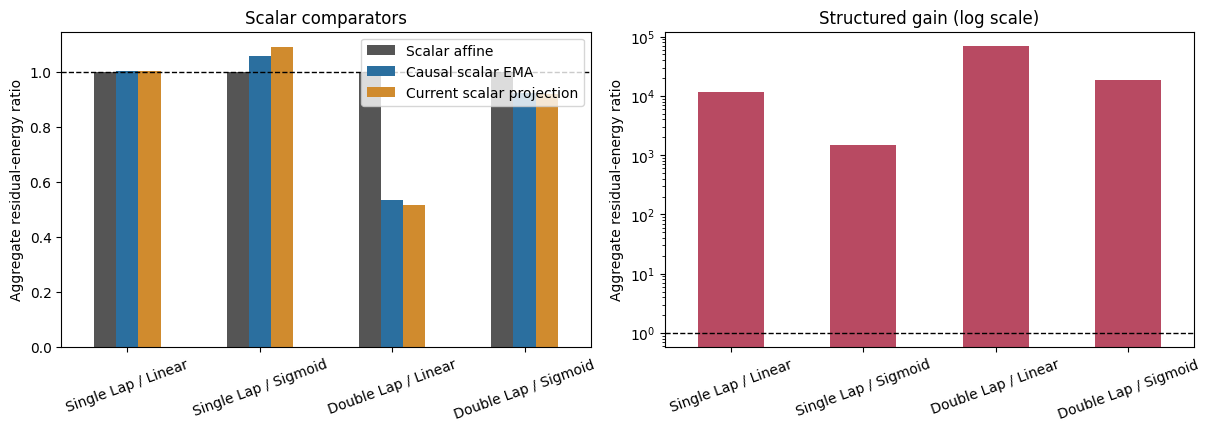

In [4]:
labels = primary['design'].str.replace('_', ' ').str.title() + ' / ' + primary['schedule'].str.title()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
scalar_columns = ['scalar_affine', 'causal_scalar_ema', 'contemporaneous_scalar_oracle']
primary.set_index(labels)[scalar_columns].rename(columns={
    'scalar_affine': 'Scalar affine', 'causal_scalar_ema': 'Causal scalar EMA',
    'contemporaneous_scalar_oracle': 'Current scalar projection'
}).plot.bar(ax=axes[0], color=['#555555', '#2b6f9f', '#d08b2e'])
axes[0].axhline(1, color='black', lw=1, ls='--')
axes[0].set(title='Scalar comparators', ylabel='Aggregate residual-energy ratio', xlabel='')
axes[0].tick_params(axis='x', rotation=20)
primary.set_index(labels)[['predictable_structured_gain']].rename(columns={'predictable_structured_gain': 'Structured gain'}).plot.bar(ax=axes[1], color='#b84a62', legend=False, logy=True)
axes[1].axhline(1, color='black', lw=1, ls='--')
axes[1].set(title='Structured gain (log scale)', ylabel='Aggregate residual-energy ratio', xlabel='')
axes[1].tick_params(axis='x', rotation=20)
plt.show()


## Interpretation

The structured estimator fails broadly, not only at reversals or in isolated outliers. Its median stepwise residual ratio ranges from hundreds to thousands at the primary half-life, and its predicted Fisher norms are severely inflated. Neighboring half-lives do not rescue any path group.

The result rejects this gain family under the present $m=4$, rank-8-plus-diagonal contract. It does **not** reject the local quadratic identity with exact nonsingular curvature. Rather, directional inversion converts small mismatch between two compressed, differently smoothed curvature summaries into enormous actuation error. The scalar restriction is much more robust, and the double-lap linear path still shows that a causal scalar gain contains useful retrospective signal. No predictive accuracy or NLL was inspected for this gate.
